In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime as dt
import datetime
import os
import time
import copy
#import numpy.ma as ma
import matplotlib.dates as md
import cmocean
import cv2
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy import interpolate

# functions

In [2]:
def my_depth_interpolator_v01(df_in,depth_interp): # interpolate in depth direction
    
    df_in.index = df_in.index.astype('float64')
    #df_in.index.union(depth_interp)
    df_in = df_in[~df_in.index.duplicated()]
    df_interp = df_in.reindex(df_in.index.union(depth_interp))
    df_interp = df_interp.interpolate('index', limit_direction ='both').loc[depth_interp]
    
    df_interp.index.name = 'depth'
    
    return df_interp

# ------------------------------------------------------------------- #

def my_wavelength_interpolator_v01(df_in,wl_interp): # interpolate in the wavelength domain
    
    df_in_tr = df_in.T
    df_in_tr.index = df_in_tr.index.astype('float64')
    #df_in_tr.index.union(wl_interp)
    df_in_tr = df_in_tr[~df_in_tr.index.duplicated()]
    df_interp_tr = df_in_tr.reindex(df_in_tr.index.union(wl_interp))
    df_interp_tr = df_interp_tr.interpolate('index', limit_direction ='both').loc[wl_interp]
    
    df_interp = df_interp_tr.T
    df_interp.index.name = 'depth'
    
    return df_interp


# ------------------------------------------------------------------- #

def read_acs_v01(prof_name1,prof_name2): # get the ACS file names (csv format) and return absorption (df_a) and attenuation (df_c) 
    df1 = pd.read_csv(prof_name1,delimiter=';')
    df1 = df1.drop(['timestep','date'], axis = 1)
    df1 = df1.set_index('depth')
    df1.columns = df1.columns.astype(float)
#     df1 = df1.dropna(axis='columns',how='all')
#     df1 = df1.dropna()
#     df1 = df1.reset_index(drop=True)

#     df2 = df1.copy()
#     df2 = df2.set_index('depth')
#     df3 = my_depth_interpolator_v01(df2,depth_interp)

#     df4 = my_wavelength_interpolator_v01(df3,wl_interp)

    df_a = df1.copy()

    df1 = pd.read_csv(prof_name2,delimiter=';')
    df1 = df1.drop(['timestep','date'], axis = 1)
    df1 = df1.set_index('depth')
    df1.columns = df1.columns.astype(float)
#     df1 = df1.dropna(axis='columns',how='all')
#     df1 = df1.dropna()
#     df1 = df1.reset_index(drop=True)

#     df2 = df1.copy()
#     df2 = df2.set_index('depth')
#     df3 = my_depth_interpolator_v01(df2,depth_interp)

#     df4 = my_wavelength_interpolator_v01(df3,wl_interp)

    df_c = df1.copy()
    
    return df_a,df_c

In [3]:
def func_acs_fit(x, a, b): # fitting exp funtion with ref wavelength at 400 nm
    return a * np.exp(-b *(x-400))



def acsa_complete_qc_v02(df_a_raw): # qc of absorption raw dataframe
    
    ###### cut the data after 720 nm
    ind_720nm = np.min(np.where(df_a_raw.columns>720)[0])
    if(~np.isnan(ind_720nm)):
        df_a_raw = df_a_raw.drop(columns=df_a_raw.columns[ind_720nm:])
        
    ###### Flag for nan values
    qc_flag_nan = 9
    df_a_nan_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
    df_a_nan_flag.iloc[0:] = 1
    df_a_nan_flag[np.array(df_a_raw.isna())] = qc_flag_nan
    
        
    ###### Flag for negative values
    qc_flag_neg = 4
    df_a_neg_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
    df_a_neg_flag.iloc[0:] = 1
    df_a_raw_neg = df_a_raw.copy()
    ind_neg = np.where(df_a_raw<0)
    for ii in range(len(ind_neg[0])):
        df_a_raw_neg.iloc[ind_neg[0][ii]][[df_a_raw_neg.columns[ind_neg[1][ii]]]] = np.nan
        df_a_neg_flag.iloc[ind_neg[0][ii]][[df_a_neg_flag.columns[ind_neg[1][ii]]]] = qc_flag_neg
        
        
    ###### Flag for spikes
    qc_flag_spk = 3
    up_percentile = 99.5
    low_percentile = 0.5
    df_a_spike_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
    df_a_spike_flag.iloc[0:] = 1
    df_a_raw_neg_spike = df_a_raw_neg.copy()
    for ii in range(len(df_a_raw.columns)):
        dum_arr = savgol_filter(np.array(df_a_raw[df_a_raw.columns[ii]]),11,3)-np.array(df_a_raw[df_a_raw.columns[ii]])
        up_bnd = np.nanpercentile(dum_arr,up_percentile)
        low_bnd = np.nanpercentile(dum_arr,low_percentile)

        ind_spike = np.where((dum_arr>up_bnd) | (dum_arr<low_bnd))[0]
        df_a_raw_neg_spike[df_a_raw_neg_spike.columns[ii]].iloc[ind_spike] = np.nan
        df_a_spike_flag[df_a_spike_flag.columns[ii]].iloc[ind_spike] = qc_flag_spk
    
        
    ###### Flag for problematic acs spectra
    df_a_raw_nan_interp = df_a_raw_neg_spike.copy()
    qc_flag_exp = 3
    log_ratio_thre = 0.3
    df_a_acs_flag = pd.DataFrame(index=df_a_raw_nan_interp.index,columns=df_a_raw_nan_interp.columns)
    df_a_acs_flag.iloc[0:] = 1
    df_a_acs_nan = df_a_raw_nan_interp.copy()

    ##############
    
    # three selected wavelengths for further quality check
    ind_530 = np.min(np.where(df_a_acs_nan.columns>530)[0])
    ind_600 = np.min(np.where(df_a_acs_nan.columns>600)[0])
    ind_430 = np.min(np.where(df_a_acs_nan.columns>430)[0])

    for ii in range(len(df_a_acs_nan.index)):
        ind1 = ~np.isnan(np.array(df_a_acs_nan.iloc[ii].iloc[:ind_530]))
        ind2 = ~np.isnan(np.array(df_a_acs_nan.iloc[ii].iloc[:ind_600]))

        try:
            popt1, pcov1 = curve_fit(func_acs_fit, np.array(df_a_acs_nan.columns[:ind_530])[ind1],np.array(df_a_acs_nan.iloc[ii].iloc[:ind_530])[ind1])
            popt2, pcov2 = curve_fit(func_acs_fit, np.array(df_a_acs_nan.columns[:ind_600])[ind2],np.array(df_a_acs_nan.iloc[ii].iloc[:ind_600])[ind2])
            yy1_hat = func_acs_fit(np.array(df_a_acs_nan.columns[:ind_530])[ind1], popt1[0], popt1[1])
            yy2_hat = func_acs_fit(np.array(df_a_acs_nan.columns[:ind_600])[ind2], popt2[0], popt2[1])
            yy1 = np.array(df_a_acs_nan.iloc[ii].iloc[:ind_530])[ind1]
            yy2 = np.array(df_a_acs_nan.iloc[ii].iloc[:ind_600])[ind2]

            if(np.corrcoef(yy2,yy2_hat)[0][1]>np.corrcoef(yy1,yy1_hat)[0][1]):
                if ((np.sqrt(np.diag(pcov2))[0]>popt2[0]/10) | (np.sqrt(np.diag(pcov2))[1]>popt2[1]/10)):
                    df_a_acs_nan.iloc[ii] = np.nan
                    df_a_acs_flag.iloc[ii] = qc_flag_exp
                else:
                    for jj in range(ind_430):
            #                     if ((abs(yy2[jj]-yy2_hat[jj])/yy2[jj])>0.3):
                        if ((abs(np.log(yy2_hat[jj]/yy2[jj])))>log_ratio_thre):
                            df_a_acs_nan.iloc[ii][jj] = np.nan
                            df_a_acs_flag.iloc[ii][jj] = qc_flag_exp
            else:
                if ((np.sqrt(np.diag(pcov1))[0]>popt1[0]/10) | (np.sqrt(np.diag(pcov1))[1]>popt1[1]/10)):
                    df_a_acs_nan.iloc[ii] = np.nan
                    df_a_acs_flag.iloc[ii] = qc_flag_exp
                else:
                    for jj in range(ind_430):
            #                     if ((abs(yy1[jj]-yy1_hat[jj])/yy1[jj])>0.3):
                        if ((abs(np.log(yy1_hat[jj]/yy1[jj])))>log_ratio_thre):
                            df_a_acs_nan.iloc[ii][jj] = np.nan
                            df_a_acs_flag.iloc[ii][jj] = qc_flag_exp

        except:
            df_a_acs_nan.iloc[ii] = np.nan
            df_a_acs_flag.iloc[ii] = qc_flag_exp
        #     print(ii)
            pass
    
        
    ###### Interpolate in the z direction
    xx,yy = np.meshgrid(np.array(df_a_acs_nan.columns), np.array(df_a_acs_nan.index))
    z_arr = np.array(df_a_acs_nan)
    z_arr = np.ma.masked_invalid(z_arr)
    x1 = xx[~z_arr.mask]
    y1 = yy[~z_arr.mask]
    newarr = z_arr[~z_arr.mask]
    if (np.size(newarr)>100):
        z_arr_interp = interpolate.griddata((x1, y1), newarr.ravel(),(xx, yy),method='linear')
        df_a_acs_nan_interp = pd.DataFrame(data=z_arr_interp,index=df_a_acs_nan.index,columns=df_a_acs_nan.columns)
        df_a_acs_nan_interp = df_a_acs_nan_interp.interpolate('index', limit_direction ='both')
    else:
        df_a_acs_nan_interp = df_a_acs_nan.copy()
        df_a_acs_nan_interp = df_a_acs_nan_interp.interpolate('index', limit_direction ='both')
    
    
    ###### Define the QC flag for all
    df_qc_flag_all = df_a_spike_flag.copy()
    df_qc_flag_all = df_qc_flag_all.mask(df_a_acs_flag==qc_flag_exp, qc_flag_exp)
    df_qc_flag_all = df_qc_flag_all.mask(df_a_neg_flag==qc_flag_neg, qc_flag_neg)
    df_qc_flag_all = df_qc_flag_all.mask(df_a_nan_flag==qc_flag_nan, qc_flag_nan)
    
    ###### Deal with the jump in the green band
    df_a_acs_nan_interp_shift = df_a_acs_nan_interp.copy()

    ind_565 = np.min(np.where(df_a_acs_nan_interp_shift.columns>565)[0])
    ind_610 = np.min(np.where(df_a_acs_nan_interp_shift.columns>610)[0])

    for ii in range(len(df_a_acs_nan_interp_shift.index)):
        xxx = np.array(df_a_acs_nan_interp_shift.columns[ind_565:ind_610])
        yyy = np.array(df_a_acs_nan_interp_shift.iloc[ii].iloc[ind_565:ind_610])
        pfit_1d = np.polyfit(xxx[-5:],yyy[-5:],1)
        adj_shift = pfit_1d[0]*np.mean(xxx[:4])+pfit_1d[1]-np.mean(yyy[:4])

        yyy_pr = yyy.copy()
        yyy_pr[0:4] = yyy_pr[0:4]+adj_shift
        yyy_pr = np.delete(yyy_pr,[4,5])
        xxx_pr = xxx.copy()
        xxx_pr = np.delete(xxx_pr,[4,5])
        yyy_shifted = np.interp(xxx,xxx_pr,yyy_pr)

        df_a_acs_nan_interp_shift.iloc[ii].iloc[0:ind_565] = df_a_acs_nan_interp_shift.iloc[ii].iloc[0:ind_565]+adj_shift
        df_a_acs_nan_interp_shift.iloc[ii].iloc[ind_565:ind_610] = yyy_shifted
        
    ###### interpolate in wl domain
    wl_res = 1
    start_wl = 400
    end_wl = 719
    wl_interp = np.arange(start_wl,end_wl+wl_res,wl_res)
    df_a_acs_nan_interp_shift_wl = my_wavelength_interpolator_v01(df_a_acs_nan_interp_shift,wl_interp)
    
    ###### smooth the data in z direction
    df_a_acs_nan_interp_shift_wl_smth = df_a_acs_nan_interp_shift_wl.copy()
    for ii in range(len(df_a_acs_nan_interp_shift_wl_smth.columns)):
        df_a_acs_nan_interp_shift_wl_smth[df_a_acs_nan_interp_shift_wl_smth.columns[ii]] = savgol_filter(np.array(df_a_acs_nan_interp_shift_wl[df_a_acs_nan_interp_shift_wl.columns[ii]]),11,3)
    
    ###### Bin the data in z direction
    depth_min_lim = 40
    depth_res = 0.5

    if (depth_min_lim>np.max(df_a_acs_nan_interp_shift_wl.index)):
        depth_min_lim = np.max(df_a_acs_nan_interp_shift_wl.index)
        depth_bins = np.arange(depth_res/2,depth_min_lim+depth_res/2,depth_res)
        edge_bins = np.arange(0,depth_min_lim+depth_res,depth_res)
    else:
        depth_bins = np.arange(depth_res/2,depth_min_lim+depth_res/2,depth_res)
        edge_bins = np.arange(0,depth_min_lim+depth_res,depth_res)

    df_a_acs_nan_interp_shift_wl_binn = pd.DataFrame(columns=df_a_acs_nan_interp_shift_wl.columns,index=depth_bins).astype('float', copy=False)

    ind_depth_bin = []
    ind_depth_bin.extend([np.nan]*len(edge_bins))
    ind_strt = np.where((depth_bins-df_a_acs_nan_interp_shift_wl.index[0])>0)[0][0]
    ind_depth_bin[ind_strt] = 0
    for ii in range(ind_strt+1,len(ind_depth_bin)):
        ind_depth_bin[ii] = np.where((df_a_acs_nan_interp_shift_wl.index-edge_bins[ii])<0)[0][-1]
        for jj in range(len(df_a_acs_nan_interp_shift_wl_binn.columns)):
            dum_val = df_a_acs_nan_interp_shift_wl[df_a_acs_nan_interp_shift_wl.columns[jj]].iloc[ind_depth_bin[ii-1]:ind_depth_bin[ii]].median()
            df_a_acs_nan_interp_shift_wl_binn[df_a_acs_nan_interp_shift_wl_binn.columns[jj]].iloc[ii-1] = dum_val
    df_a_acs_nan_interp_shift_wl_binn = df_a_acs_nan_interp_shift_wl_binn.interpolate('index', limit_direction ='both')
    
    
    return df_a_acs_nan_interp,df_a_acs_nan_interp_shift,df_a_acs_nan_interp_shift_wl,df_a_acs_nan_interp_shift_wl_smth,df_a_acs_nan_interp_shift_wl_binn,df_qc_flag_all

In [4]:
def acsc_complete_qc_v02(df_a_raw): # qc of attenuation raw dataframe
    
    ###### cut the data after 720 nm
    ind_720nm = np.min(np.where(df_a_raw.columns>720)[0])
    if(~np.isnan(ind_720nm)):
        df_a_raw = df_a_raw.drop(columns=df_a_raw.columns[ind_720nm:])
        
    ###### Flag for nan values
    qc_flag_nan = 9
    df_a_nan_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
    df_a_nan_flag.iloc[0:] = 1
    df_a_nan_flag[np.array(df_a_raw.isna())] = qc_flag_nan
    
        
    ###### Flag for negative values
    qc_flag_neg = 4
    df_a_neg_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
    df_a_neg_flag.iloc[0:] = 1
    df_a_raw_neg = df_a_raw.copy()
    ind_neg = np.where(df_a_raw<0)
    for ii in range(len(ind_neg[0])):
        df_a_raw_neg.iloc[ind_neg[0][ii]][[df_a_raw_neg.columns[ind_neg[1][ii]]]] = np.nan
        df_a_neg_flag.iloc[ind_neg[0][ii]][[df_a_neg_flag.columns[ind_neg[1][ii]]]] = qc_flag_neg
        
        
    ###### Flag for spikes
    qc_flag_spk = 3
    up_percentile = 99.5
    low_percentile = 0.5
    df_a_spike_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
    df_a_spike_flag.iloc[0:] = 1
    df_a_raw_neg_spike = df_a_raw_neg.copy()
    for ii in range(len(df_a_raw.columns)):
        dum_arr = savgol_filter(np.array(df_a_raw[df_a_raw.columns[ii]]),11,3)-np.array(df_a_raw[df_a_raw.columns[ii]])
        up_bnd = np.nanpercentile(dum_arr,up_percentile)
        low_bnd = np.nanpercentile(dum_arr,low_percentile)

        ind_spike = np.where((dum_arr>up_bnd) | (dum_arr<low_bnd))[0]
        df_a_raw_neg_spike[df_a_raw_neg_spike.columns[ii]].iloc[ind_spike] = np.nan
        df_a_spike_flag[df_a_spike_flag.columns[ii]].iloc[ind_spike] = qc_flag_spk
    
        
    ###### Interpolate in the z direction
    df_a_acs_nan = df_a_raw_neg_spike.copy()
    xx,yy = np.meshgrid(np.array(df_a_acs_nan.columns), np.array(df_a_acs_nan.index))
    z_arr = np.array(df_a_acs_nan)
    z_arr = np.ma.masked_invalid(z_arr)
    x1 = xx[~z_arr.mask]
    y1 = yy[~z_arr.mask]
    newarr = z_arr[~z_arr.mask]
    if (np.size(newarr)>100):
        z_arr_interp = interpolate.griddata((x1, y1), newarr.ravel(),(xx, yy),method='linear')
        df_a_acs_nan_interp = pd.DataFrame(data=z_arr_interp,index=df_a_acs_nan.index,columns=df_a_acs_nan.columns)
        df_a_acs_nan_interp = df_a_acs_nan_interp.interpolate('index', limit_direction ='both')
    else:
        df_a_acs_nan_interp = df_a_acs_nan.copy()
        df_a_acs_nan_interp = df_a_acs_nan_interp.interpolate('index', limit_direction ='both')
    
    ###### Define the QC flag for all
    df_qc_flag_all = df_a_spike_flag.copy()
    df_qc_flag_all = df_qc_flag_all.mask(df_a_neg_flag==qc_flag_neg, qc_flag_neg)
    df_qc_flag_all = df_qc_flag_all.mask(df_a_nan_flag==qc_flag_nan, qc_flag_nan)
    
    
    ###### interpolate in wl domain
    wl_res = 1
    start_wl = 400
    end_wl = 719
    wl_interp = np.arange(start_wl,end_wl+wl_res,wl_res)
    df_a_acs_nan_interp_wl = my_wavelength_interpolator_v01(df_a_acs_nan_interp,wl_interp)
    
    ###### smooth the data in z direction
    df_a_acs_nan_interp_wl_smth = df_a_acs_nan_interp_wl.copy()
    for ii in range(len(df_a_acs_nan_interp_wl_smth.columns)):
        df_a_acs_nan_interp_wl_smth[df_a_acs_nan_interp_wl_smth.columns[ii]] = savgol_filter(np.array(df_a_acs_nan_interp_wl[df_a_acs_nan_interp_wl.columns[ii]]),11,3)
    
    ###### Bin the data in z direction
    depth_min_lim = 40
    depth_res = 0.5

    if (depth_min_lim>np.max(df_a_acs_nan_interp_wl.index)):
        depth_min_lim = np.max(df_a_acs_nan_interp_wl.index)
        depth_bins = np.arange(depth_res/2,depth_min_lim+depth_res/2,depth_res)
        edge_bins = np.arange(0,depth_min_lim+depth_res,depth_res)
    else:
        depth_bins = np.arange(depth_res/2,depth_min_lim+depth_res/2,depth_res)
        edge_bins = np.arange(0,depth_min_lim+depth_res,depth_res)

    df_a_acs_nan_interp_wl_binn = pd.DataFrame(columns=df_a_acs_nan_interp_wl.columns,index=depth_bins).astype('float', copy=False)

    ind_depth_bin = []
    ind_depth_bin.extend([np.nan]*len(edge_bins))
    ind_strt = np.where((depth_bins-df_a_acs_nan_interp_wl.index[0])>0)[0][0]
    ind_depth_bin[ind_strt] = 0
    for ii in range(ind_strt+1,len(ind_depth_bin)):
        ind_depth_bin[ii] = np.where((df_a_acs_nan_interp_wl.index-edge_bins[ii])<0)[0][-1]
        for jj in range(len(df_a_acs_nan_interp_wl_binn.columns)):
            dum_val = df_a_acs_nan_interp_wl[df_a_acs_nan_interp_wl.columns[jj]].iloc[ind_depth_bin[ii-1]:ind_depth_bin[ii]].median()
            df_a_acs_nan_interp_wl_binn[df_a_acs_nan_interp_wl_binn.columns[jj]].iloc[ii-1] = dum_val
    df_a_acs_nan_interp_wl_binn = df_a_acs_nan_interp_wl_binn.interpolate('index', limit_direction ='both')
    
    
    return df_a_acs_nan_interp,df_a_acs_nan_interp_wl,df_a_acs_nan_interp_wl_smth,df_a_acs_nan_interp_wl_binn,df_qc_flag_all

# Sync all the data

In [5]:
Thetis_input_data_path = 'E:\\HyperStrata\\02_data&measurements\\LeXplore\Thetis\\Data\\All_data'
os.chdir(Thetis_input_data_path)

# Create a list with all the files
path = os.getcwd()
allfiles = os.listdir(path)
# Select different files
acsafiles = [f for f in allfiles if f[-9:] == "ACS_a.csv"]
acsafiles = [f for f in acsafiles if f[0] != "~"] # in case there is an open file

acscfiles = [f for f in allfiles if f[-9:] == "ACS_c.csv"]
acscfiles = [f for f in acscfiles if f[0] != "~"] # in case there is an open file

################

date_timestamp_ls_acsa = [time.mktime(dt.strptime(acsafiles[ii][0:15], '%Y%m%d_%HH%MM').timetuple()) for ii in range(len(acsafiles))]
date_timestamp_ls_acsc = [time.mktime(dt.strptime(acscfiles[ii][0:15], '%Y%m%d_%HH%MM').timetuple()) for ii in range(len(acscfiles))]

sync_timestamp = list(set(date_timestamp_ls_acsa) & set(date_timestamp_ls_acsc))


###############

ab,a_ind,b_ind=np.intersect1d(date_timestamp_ls_acsa, sync_timestamp,return_indices=True)
acsafiles = [acsafiles[a_ind[ii]] for ii in range(len(a_ind))]

ab,a_ind,b_ind=np.intersect1d(date_timestamp_ls_acsc, sync_timestamp,return_indices=True)
acscfiles = [acscfiles[a_ind[ii]] for ii in range(len(a_ind))]

# timestapms are syncheronized now.
date_timestamp_ls_acsa = [time.mktime(dt.strptime(acsafiles[ii][0:15], '%Y%m%d_%HH%MM').timetuple()) for ii in range(len(acsafiles))]
date_timestamp_ls_acsc = [time.mktime(dt.strptime(acscfiles[ii][0:15], '%Y%m%d_%HH%MM').timetuple()) for ii in range(len(acscfiles))]

# Test the functions

In [6]:
date_target = dt.timestamp(dt.strptime('20190612_14H59M', '%Y%m%d_%HH%MM'))
ind_fname = np.where(abs(np.array(date_timestamp_ls_acsa)-date_target) == min(abs(np.array(date_timestamp_ls_acsa)-date_target)))[0][0]

df_a_raw,df_c_raw = read_acs_v01(acsafiles[ind_fname],acscfiles[ind_fname])

df_a_acs_nan_interp,df_a_acs_nan_interp_shift,df_a_acs_nan_interp_shift_wl,df_a_acs_nan_interp_shift_wl_smth,df_a_acs_nan_interp_shift_wl_binn,qc_a_flag_all = acsa_complete_qc_v02(df_a_raw) 
df_c_acs_nan_interp,df_c_acs_nan_interp_wl,df_c_acs_nan_interp_wl_smth,df_c_acs_nan_interp_wl_binn,qc_c_flag_all = acsc_complete_qc_v02(df_c_raw) 


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: overflow encountered in exp
  
C:\ProgramData\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: overflow encountered in multiply
  


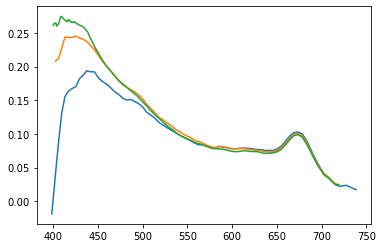

In [7]:
plt.plot(df_a_raw.iloc[47].iloc[0:])
plt.hold = True
plt.plot(df_a_acs_nan_interp.iloc[47].iloc[1:])
plt.plot(df_a_acs_nan_interp_shift_wl_binn.iloc[1])

In [8]:
qc_a_flag_all

,398.5,402.6,406.2,409.6,413.2,416.9,421.0,425.4,429.7,433.6,...,682.0,686.4,690.5,694.7,698.8,702.6,707.0,711.0,715.0,719.0
depth,,,,,,,,,,,,,,,,,,,,,
0.199487,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
0.224606,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
0.249238,1,3,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
0.270857,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
0.299458,3,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58.615083,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
58.617378,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
58.617521,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


# Read all the data and save the flags

In [9]:
# df_qc_a_flag_all = pd.DataFrame(index = date_timestamp_ls_acsa,columns = ['n_tot','n_flag_nan','n_flag_negative','n_flag_suspect'])
# df_qc_c_flag_all = pd.DataFrame(index = date_timestamp_ls_acsc,columns = ['n_tot','n_flag_nan','n_flag_negative','n_flag_suspect'])

In [10]:
# for ind_fname in range(len(acsafiles)):
#     df_a_raw,df_c_raw = read_acs_v01(acsafiles[ind_fname],acscfiles[ind_fname])
    
#     if ((np.min(df_a_raw.index)<2) & ((np.min(df_c_raw.index)<2))):
#         df_a_acs_nan_interp,df_a_acs_nan_interp_shift,df_a_acs_nan_interp_shift_wl,df_a_acs_nan_interp_shift_wl_smth,df_a_acs_nan_interp_shift_wl_binn,qc_a_flag_all = acsa_complete_qc_v02(df_a_raw) 
#         df_c_acs_nan_interp,df_c_acs_nan_interp_wl,df_c_acs_nan_interp_wl_smth,df_c_acs_nan_interp_wl_binn,qc_c_flag_all = acsc_complete_qc_v02(df_c_raw) 

#         df_qc_a_flag_all['n_flag_nan'].iloc[ind_fname] = len(np.where(qc_a_flag_all==9)[0])
#         df_qc_a_flag_all['n_flag_negative'].iloc[ind_fname] = len(np.where(qc_a_flag_all==4)[0])
#         df_qc_a_flag_all['n_flag_suspect'].iloc[ind_fname] = len(np.where(qc_a_flag_all==3)[0])
#         df_qc_a_flag_all['n_tot'].iloc[ind_fname] = np.size(qc_a_flag_all)

#         df_qc_c_flag_all['n_flag_nan'].iloc[ind_fname] = len(np.where(qc_c_flag_all==9)[0])
#         df_qc_c_flag_all['n_flag_negative'].iloc[ind_fname] = len(np.where(qc_c_flag_all==4)[0])
#         df_qc_c_flag_all['n_flag_suspect'].iloc[ind_fname] = len(np.where(qc_c_flag_all==3)[0])
#         df_qc_c_flag_all['n_tot'].iloc[ind_fname] = np.size(qc_c_flag_all)

In [11]:
# df_qc_a_flag_all.to_csv('E:/HyperStrata/02_data&measurements/LeXplore/Thetis/Data/ACS_QC/df_qc_a_flag_all.csv',index=True)
# df_qc_c_flag_all.to_csv('E:/HyperStrata/02_data&measurements/LeXplore/Thetis/Data/ACS_QC/df_qc_c_flag_all.csv',index=True)

# QC main procedure

In [12]:
# date_target = dt.timestamp(dt.strptime('20190612_14H59M', '%Y%m%d_%HH%MM'))
# ind_fname = np.where(abs(np.array(date_timestamp_ls_acsa)-date_target) == min(abs(np.array(date_timestamp_ls_acsa)-date_target)))[0][0]

# df_a_raw,df_c_raw = read_acs_v01(acsafiles[ind_fname],acscfiles[ind_fname])

In [13]:
# plt.plot(df_a_raw.columns,df_a_raw.iloc[47])
# plt.hold = True
# plt.plot(df_a_raw.columns,df_a_raw.iloc[30])

## Keep the data up to 720 nm

In [14]:
# ind_720nm = np.min(np.where(df_a_raw.columns>720)[0])
# if(~np.isnan(ind_720nm)):
#     df_a_raw = df_a_raw.drop(columns=df_a_raw.columns[ind_720nm:])

## Flag for NaN values

In [15]:
# qc_flag_nan = 9
# df_a_nan_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
# df_a_nan_flag.iloc[0:] = 1
# df_a_nan_flag[np.array(df_a_raw.isna())] = qc_flag_nan
# n_tot_nan = 0
# if (len(np.where(df_a_nan_flag==qc_flag_nan)[0])>0):
#     n_tot_nan = len(np.where(df_a_nan_flag==qc_flag_nan)[0])

## Flag for negative values

In [16]:
# qc_flag_neg = 4
# df_a_neg_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
# df_a_neg_flag.iloc[0:] = 1
# df_a_raw_neg = df_a_raw.copy()
# ind_neg = np.where(df_a_raw<0)
# for ii in range(len(ind_neg[0])):
#     df_a_raw_neg.iloc[ind_neg[0][ii]][[df_a_raw_neg.columns[ind_neg[1][ii]]]] = np.nan
#     df_a_neg_flag.iloc[ind_neg[0][ii]][[df_a_neg_flag.columns[ind_neg[1][ii]]]] = qc_flag_neg
# n_tot_neg = 0
# if (len(np.where(df_a_neg_flag==qc_flag_neg)[0])>0):
#     n_tot_neg = len(np.where(df_a_neg_flag==qc_flag_neg)[0])

## Flag for spikes

In [17]:
# qc_flag_spk = 3
# up_percentile = 99.5
# low_percentile = 0.5
# df_a_spike_flag = pd.DataFrame(index=df_a_raw.index,columns=df_a_raw.columns)
# df_a_spike_flag.iloc[0:] = 1
# df_a_raw_neg_spike = df_a_raw_neg.copy()
# for ii in range(len(df_a_raw.columns)):
#     dum_arr = savgol_filter(np.array(df_a_raw[df_a_raw.columns[ii]]),11,3)-np.array(df_a_raw[df_a_raw.columns[ii]])
#     up_bnd = np.nanpercentile(dum_arr,up_percentile)
#     low_bnd = np.nanpercentile(dum_arr,low_percentile)

#     ind_spike = np.where((dum_arr>up_bnd) | (dum_arr<low_bnd))[0]
#     df_a_raw_neg_spike[df_a_raw_neg_spike.columns[ii]].iloc[ind_spike] = np.nan
#     df_a_spike_flag[df_a_spike_flag.columns[ii]].iloc[ind_spike] = qc_flag_spk
# n_tot_spk = 0
# if (len(np.where(df_a_spike_flag==qc_flag_spk)[0])>0):
#     n_tot_spk = len(np.where(df_a_spike_flag==qc_flag_spk)[0])

In [18]:
# plt.plot(df_a_spike_flag.iloc[47])

## Flag for problematic acs spectra

In [19]:
# def func_acs_fit(x, a, b):
#     return a * np.exp(-b *(x-400))

In [20]:
# df_a_raw_nan_interp = df_a_raw_neg_spike.copy()
# qc_flag_exp = 3
# log_ratio_thre = 0.3
# df_a_acs_flag = pd.DataFrame(index=df_a_raw_nan_interp.index,columns=df_a_raw_nan_interp.columns)
# df_a_acs_flag.iloc[0:] = 1
# df_a_acs_nan = df_a_raw_nan_interp.copy()

# ##############

# ind_530 = np.min(np.where(df_a_acs_nan.columns>530)[0])
# ind_600 = np.min(np.where(df_a_acs_nan.columns>600)[0])
# ind_430 = np.min(np.where(df_a_acs_nan.columns>430)[0])

# for ii in range(len(df_a_acs_nan.index)):
#     ind1 = ~np.isnan(np.array(df_a_acs_nan.iloc[ii].iloc[:ind_530]))
#     ind2 = ~np.isnan(np.array(df_a_acs_nan.iloc[ii].iloc[:ind_600]))
    
#     try:
#         popt1, pcov1 = curve_fit(func_acs_fit, np.array(df_a_acs_nan.columns[:ind_530])[ind1],np.array(df_a_acs_nan.iloc[ii].iloc[:ind_530])[ind1])
#         popt2, pcov2 = curve_fit(func_acs_fit, np.array(df_a_acs_nan.columns[:ind_600])[ind2],np.array(df_a_acs_nan.iloc[ii].iloc[:ind_600])[ind2])
#         yy1_hat = func_acs_fit(np.array(df_a_acs_nan.columns[:ind_530])[ind1], popt1[0], popt1[1])
#         yy2_hat = func_acs_fit(np.array(df_a_acs_nan.columns[:ind_600])[ind2], popt2[0], popt2[1])
#         yy1 = np.array(df_a_acs_nan.iloc[ii].iloc[:ind_530])[ind1]
#         yy2 = np.array(df_a_acs_nan.iloc[ii].iloc[:ind_600])[ind2]

#         if(np.corrcoef(yy2,yy2_hat)[0][1]>np.corrcoef(yy1,yy1_hat)[0][1]):
#             if ((np.sqrt(np.diag(pcov2))[0]>popt2[0]/10) | (np.sqrt(np.diag(pcov2))[1]>popt2[1]/10)):
#                 df_a_acs_nan.iloc[ii] = np.nan
#                 df_a_acs_flag.iloc[ii] = qc_flag_exp
#             else:
#                 for jj in range(ind_430):
#         #                     if ((abs(yy2[jj]-yy2_hat[jj])/yy2[jj])>0.3):
#                     if ((abs(np.log(yy2_hat[jj]/yy2[jj])))>log_ratio_thre):
#                         df_a_acs_nan.iloc[ii][jj] = np.nan
#                         df_a_acs_flag.iloc[ii][jj] = qc_flag_exp
#         else:
#             if ((np.sqrt(np.diag(pcov1))[0]>popt1[0]/10) | (np.sqrt(np.diag(pcov1))[1]>popt1[1]/10)):
#                 df_a_acs_nan.iloc[ii] = np.nan
#                 df_a_acs_flag.iloc[ii] = qc_flag_exp
#             else:
#                 for jj in range(ind_430):
#         #                     if ((abs(yy1[jj]-yy1_hat[jj])/yy1[jj])>0.3):
#                     if ((abs(np.log(yy1_hat[jj]/yy1[jj])))>log_ratio_thre):
#                         df_a_acs_nan.iloc[ii][jj] = np.nan
#                         df_a_acs_flag.iloc[ii][jj] = qc_flag_exp
    
#     except:
#         df_a_acs_nan.iloc[ii] = np.nan
#         df_a_acs_flag.iloc[ii] = qc_flag_exp
#     #     print(ii)
#         pass
# n_tot_exp = 0
# if (len(np.where(df_a_acs_flag==qc_flag_exp)[0])>0):
#     n_tot_exp = len(np.where(df_a_acs_flag==qc_flag_exp)[0])

## Interpolate the data in z direction

In [21]:
# xx,yy = np.meshgrid(np.array(df_a_acs_nan.columns), np.array(df_a_acs_nan.index))
# z_arr = np.array(df_a_acs_nan)
# z_arr = np.ma.masked_invalid(z_arr)
# x1 = xx[~z_arr.mask]
# y1 = yy[~z_arr.mask]
# newarr = z_arr[~z_arr.mask]
# z_arr_interp = interpolate.griddata((x1, y1), newarr.ravel(),(xx, yy),method='linear')
# df_a_acs_nan_interp = pd.DataFrame(data=z_arr_interp,index=df_a_acs_nan.index,columns=df_a_acs_nan.columns)
# df_a_acs_nan_interp = df_a_acs_nan_interp.interpolate('index', limit_direction ='both')

In [22]:
# plt.plot(df_a_raw.iloc[47])

# plt.plot(df_a_acs_nan_interp.iloc[47].iloc[1:])

## Define the QC flag for all

In [23]:
# df_qc_flag_all = df_a_spike_flag.copy()
# df_qc_flag_all = df_qc_flag_all.mask(df_a_acs_flag==qc_flag_exp, qc_flag_exp)
# df_qc_flag_all = df_qc_flag_all.mask(df_a_neg_flag==qc_flag_neg, qc_flag_neg)
# df_qc_flag_all = df_qc_flag_all.mask(df_a_nan_flag==qc_flag_nan, qc_flag_nan)

# n_tot_error = len(np.where(df_qc_flag_all>1)[0])
# np.size(df_qc_flag_all)

In [24]:
# df_qc_flag_all

## Deal with the jump in the green band

In [25]:
# df_a_acs_nan_interp_shift = df_a_acs_nan_interp.copy()

# ind_565 = np.min(np.where(df_a_acs_nan_interp_shift.columns>565)[0])
# ind_610 = np.min(np.where(df_a_acs_nan_interp_shift.columns>610)[0])

# for ii in range(len(df_a_acs_nan_interp_shift.index)):
#     xxx = np.array(df_a_acs_nan_interp_shift.columns[ind_565:ind_610])
#     yyy = np.array(df_a_acs_nan_interp_shift.iloc[ii].iloc[ind_565:ind_610])
#     pfit_1d = np.polyfit(xxx[-5:],yyy[-5:],1)
#     adj_shift = pfit_1d[0]*np.mean(xxx[:4])+pfit_1d[1]-np.mean(yyy[:4])
    
#     yyy_pr = yyy.copy()
#     yyy_pr[0:4] = yyy_pr[0:4]+adj_shift
#     yyy_pr = np.delete(yyy_pr,[4,5])
#     xxx_pr = xxx.copy()
#     xxx_pr = np.delete(xxx_pr,[4,5])
#     yyy_shifted = np.interp(xxx,xxx_pr,yyy_pr)

#     df_a_acs_nan_interp_shift.iloc[ii].iloc[0:ind_565] = df_a_acs_nan_interp_shift.iloc[ii].iloc[0:ind_565]+adj_shift
#     df_a_acs_nan_interp_shift.iloc[ii].iloc[ind_565:ind_610] = yyy_shifted

In [26]:
# plt.plot(df_a_raw.iloc[47])
# plt.plot(df_a_acs_nan_interp.iloc[47].iloc[1:])
# plt.plot(df_a_acs_nan_interp_shift.iloc[47].iloc[1:])

In [27]:
# df_a_acs_nan_interp_shift

## Interpolate in wl direction

In [28]:
# wl_res = 1
# start_wl = 400
# end_wl = 719

# wl_interp = np.arange(start_wl,end_wl+wl_res,wl_res)

# df_a_acs_nan_interp_shift_wl = my_wavelength_interpolator_v01(df_a_acs_nan_interp_shift,wl_interp)

## Smooth the data in y direction

In [29]:
# df_a_acs_nan_interp_shift_wl_smth = df_a_acs_nan_interp_shift_wl.copy()
# for ii in range(len(df_a_acs_nan_interp_shift_wl_smth.columns)):
#     df_a_acs_nan_interp_shift_wl_smth[df_a_acs_nan_interp_shift_wl_smth.columns[ii]] = savgol_filter(np.array(df_a_acs_nan_interp_shift_wl[df_a_acs_nan_interp_shift_wl.columns[ii]]),11,3)

In [30]:
# jj = 0
# plt.plot(df_a_acs_nan_interp_shift_wl[df_a_acs_nan_interp_shift_wl.columns[jj]],-df_a_acs_nan_interp_shift_wl.index)
# plt.hold = True
# plt.plot(df_a_acs_nan_interp_shift_wl_smth[df_a_acs_nan_interp_shift_wl_smth.columns[jj]],-df_a_acs_nan_interp_shift_wl_smth.index)

## Bin the data in y direction

In [31]:
# depth_min_lim = 50
# depth_res = 0.5

# if (depth_min_lim>np.max(df_a_acs_nan_interp_shift_wl.index)):
#     depth_min_lim = np.max(df_a_acs_nan_interp_shift_wl.index)
#     depth_bins = np.arange(depth_res/2,depth_min_lim+depth_res/2,depth_res)
#     edge_bins = np.arange(0,depth_min_lim+depth_res,depth_res)
# else:
#     depth_bins = np.arange(depth_res/2,depth_min_lim+depth_res/2,depth_res)
#     edge_bins = np.arange(0,depth_min_lim+depth_res,depth_res)
    
# df_a_acs_nan_interp_shift_wl_binn = pd.DataFrame(columns=df_a_acs_nan_interp_shift_wl.columns,index=depth_bins).astype('float', copy=False)

# ind_depth_bin = []
# ind_depth_bin.extend([np.nan]*len(edge_bins))
# ind_strt = np.where((depth_bins-df_a_acs_nan_interp_shift_wl.index[0])>0)[0][0]
# ind_depth_bin[ind_strt] = 0
# for ii in range(ind_strt+1,len(ind_depth_bin)):
#     ind_depth_bin[ii] = np.where((df_a_acs_nan_interp_shift_wl.index-edge_bins[ii])<0)[0][-1]
#     for jj in range(len(df_a_acs_nan_interp_shift_wl_binn.columns)):
#         dum_val = df_a_acs_nan_interp_shift_wl[df_a_acs_nan_interp_shift_wl.columns[jj]].iloc[ind_depth_bin[ii-1]:ind_depth_bin[ii]].median()
#         df_a_acs_nan_interp_shift_wl_binn[df_a_acs_nan_interp_shift_wl_binn.columns[jj]].iloc[ii-1] = dum_val
# df_a_acs_nan_interp_shift_wl_binn = df_a_acs_nan_interp_shift_wl_binn.interpolate('index', limit_direction ='both')

In [32]:
# jj = 149
# plt.plot(df_a_acs_nan_interp_shift_wl[df_a_acs_nan_interp_shift_wl.columns[jj]],-df_a_acs_nan_interp_shift_wl.index)
# plt.hold = True
# # plt.plot(df_a_acs_nan_interp_shift_wl_smth[df_a_acs_nan_interp_shift_wl_smth.columns[jj]],-df_a_acs_nan_interp_shift_wl_smth.index)
# plt.plot(df_a_acs_nan_interp_shift_wl_binn[df_a_acs_nan_interp_shift_wl_binn.columns[jj]],-df_a_acs_nan_interp_shift_wl_binn.index)

# Sample plot for Camille's paper

Text(0, 0.5, '$\\mathregular{a \\ [m^{-1}]}$')

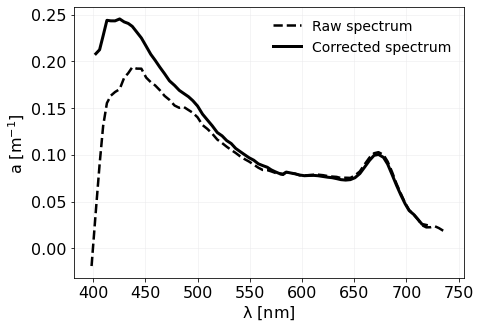

In [33]:
lw_size = 3
font_feature = ['sans-serif', 16, 16] # [fontname, fontsize_labels, fontsize_ticks]

fig_size = (7,5)
fig = plt.figure(figsize=fig_size)
plt.grid(color='#EBEAED', linestyle='-', linewidth=0.5)
plt.hold=True
plt.plot(df_a_raw.iloc[47],'--',color='k', lw=2.5,label='Raw spectrum')
plt.plot(df_a_acs_nan_interp.iloc[47].iloc[1:],color='k', lw=lw_size,label='Corrected spectrum')
plt.yticks(fontname=font_feature[0],fontsize=font_feature[2])
plt.xticks(fontname=font_feature[0],fontsize=font_feature[2])

leg = plt.legend(facecolor = 'k',frameon=False, prop={"size":font_feature[1]-2,'family':font_feature[0]})
plt.setp(leg.get_texts(), color='k')

xy_lbl = ['$\mathregular{\lambda \ [nm]}$','$\mathregular{a \ [m^{-1}]}$'] # [xlaebl, ylabel]
plt.xlabel(xy_lbl[0], fontsize= font_feature[1],fontname=font_feature[0])
plt.ylabel(xy_lbl[1], fontsize= font_feature[1],fontname=font_feature[0])

# plt.savefig('E:/HyperStrata/02_data&measurements/LeXplore/Thetis/Data/ACS_QC/acs_a_qc_20190612.png',dpi=300, bbox_inches = 'tight')